In [1]:
import numpy as np
import matplotlib.pyplot as plt
import firtez_dz as frz
from astropy.io import fits
from matplotlib.colors import CenteredNorm, TwoSlopeNorm

In [2]:
plt.rc('text', usetex = False)

## 45 degree rotation with MURaM simulation

In [3]:
atm_ori = frz.read_model('/dat/xenosh/muram_plage_pore/theta_test/muram_020000_nx1536_ny1536_nz240_d6.bin')

In [4]:
atm = frz.read_model('/dat/xenosh/muram_plage_pore/theta_test/out_muram_020000_nx1536_ny1536_nz240_d6.bin')

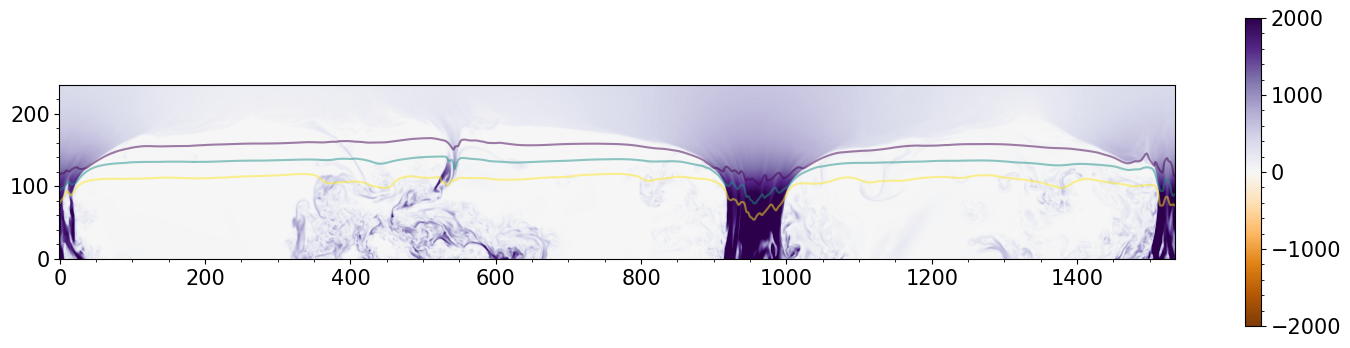

In [63]:
plt.figure(figsize=(18,4))
plt.imshow(np.sqrt(atm_ori.bx[:,756,:]**2+atm_ori.by[:,756,:]**2+atm_ori.bz[:,756,:]**2).T,origin='lower',cmap='PuOr',vmax=2000,vmin=-2000)
plt.colorbar()
plt.contour(atm_ori.tau[:,756,:].T,levels=[-2,-1,0],alpha=0.5)

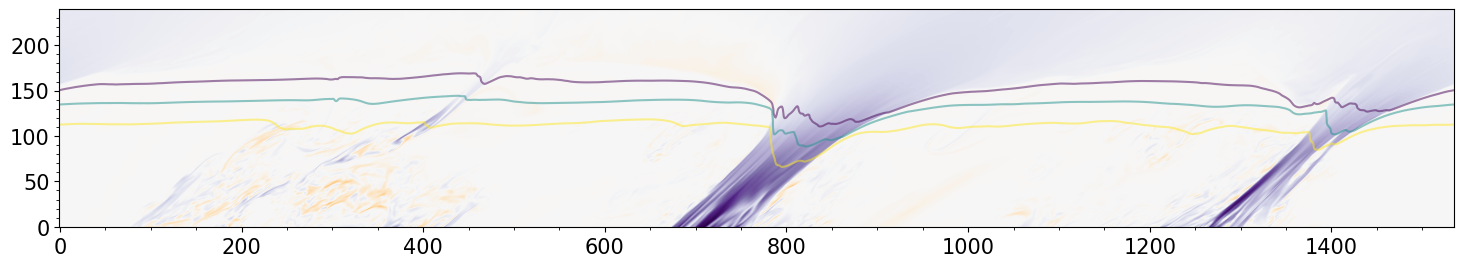

In [68]:
plt.figure(figsize=(18,4))
plt.imshow(atm.bz[:,756,:].T,origin='lower',cmap='PuOr',norm=CenteredNorm())
#plt.colorbar()
plt.contour(atm.tau[:,756,:].T,levels=[-2,-1,0],alpha=0.5)

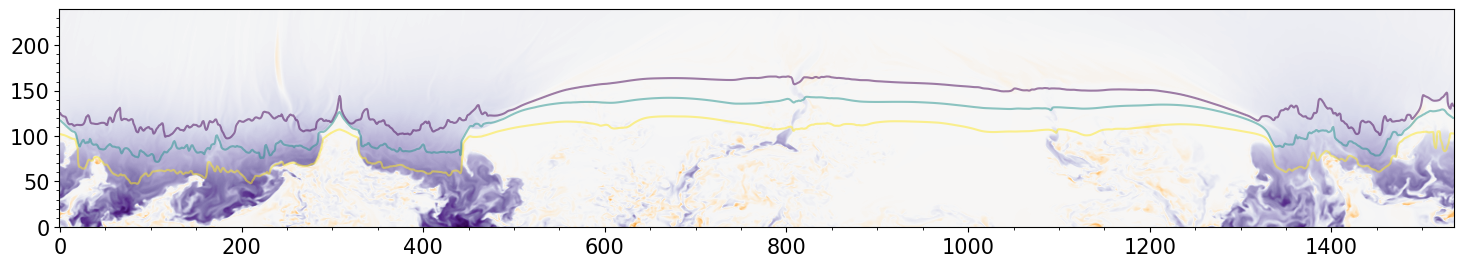

In [82]:
plt.figure(figsize=(18,4))
plt.imshow(atm.bz[350,:,:].T,origin='lower',cmap='PuOr',norm=CenteredNorm())
#plt.colorbar()
plt.contour(atm.tau[350,:,:].T,levels=[-2,-1,0],alpha=0.5)

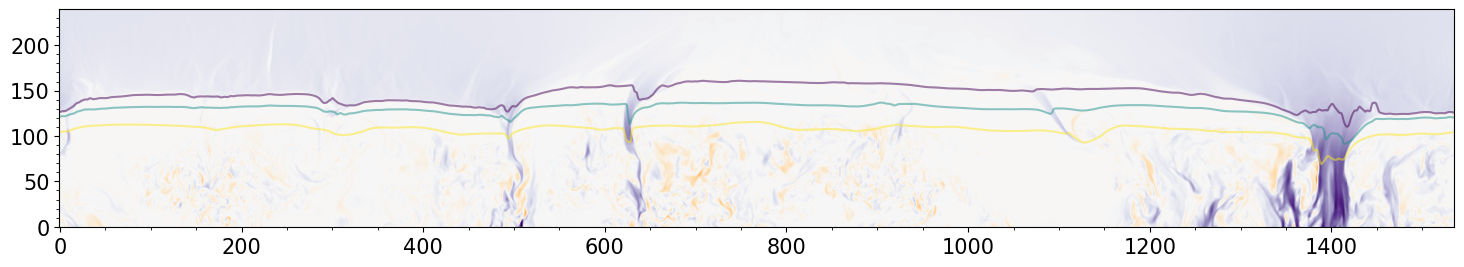

In [83]:
plt.figure(figsize=(18,4))
plt.imshow(atm_ori.bz[350,:,:].T,origin='lower',cmap='PuOr',norm=CenteredNorm())
#plt.colorbar()
plt.contour(atm_ori.tau[350,:,:].T,levels=[-2,-1,0],alpha=0.5)

In [5]:
stokes = frz.read_profile('/dat/xenosh/muram_plage_pore/theta_test/stokes.bin')

In [116]:
stokes = frz.read_profile('/dat/xenosh/muram_plage_pore/30degree/stokes.bin')

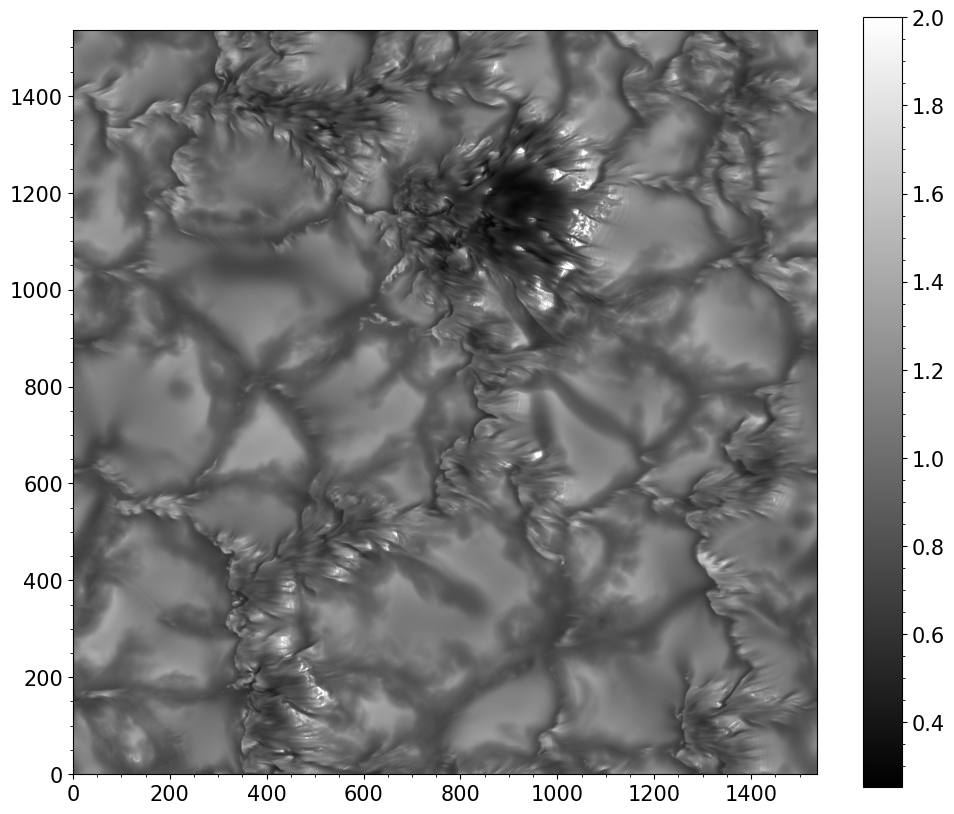

In [117]:
plt.figure(figsize=(12,10))
plt.imshow(stokes.stki[100,:,:].T,origin='lower',cmap='gray',vmax=2)
plt.colorbar()

In [14]:
np.cos(np.pi/4)

0.7071067811865476

In [17]:
np.arccos(0.85)*180/np.pi

31.78833061705162

In [6]:
# interpolate
tau_common = np.linspace(-3,1,41)
nx = atm.tem.shape[0]
ny = atm.tem.shape[1]
nz = tau_common.shape[0]
T= np.zeros((nx,ny,nz))
P= np.zeros((nx,ny,nz))
Bx= np.zeros((nx,ny,nz))
By= np.zeros((nx,ny,nz))
Bz= np.zeros((nx,ny,nz))
Vz= np.zeros((nx,ny,nz))
Bh = np.zeros((nx,ny,nz))
a = np.zeros((nz))
z = np.zeros((nx,ny,nz))
z0 = np.zeros((nx,ny,nz))
for i in range(nx):
    for j in range(ny):
        T[i,j,:] = np.interp(tau_common, atm.tau[i,j,::-1], atm.tem[i,j,::-1])
        a = np.interp(tau_common, atm.tau[i,j,::-1], np.log10(atm.pg[i,j,::-1]))
        P[i,j,:] = 10 ** a
        Bx[i,j,:] = np.interp(tau_common, atm.tau[i,j,::-1], atm.bx[i,j,::-1])
        By[i,j,:] = np.interp(tau_common, atm.tau[i,j,::-1], atm.by[i,j,::-1])
        Bz[i,j,:] = np.interp(tau_common, atm.tau[i,j,::-1], atm.bz[i,j,::-1])
        Vz[i,j,:] = np.interp(tau_common, atm.tau[i,j,::-1], atm.vz[i,j,::-1])
        Bh[i,j,:] = np.sqrt(Bx[i,j,:]**2+By[i,j,:]**2)
        z[i,j,:] = np.interp(tau_common,atm.tau[i,j,::-1],atm.z[i,j,::-1])
        z0[i,j,:] = np.interp(tau_common,atm_ori.tau[i,j,::-1],atm_ori.z[i,j,::-1])


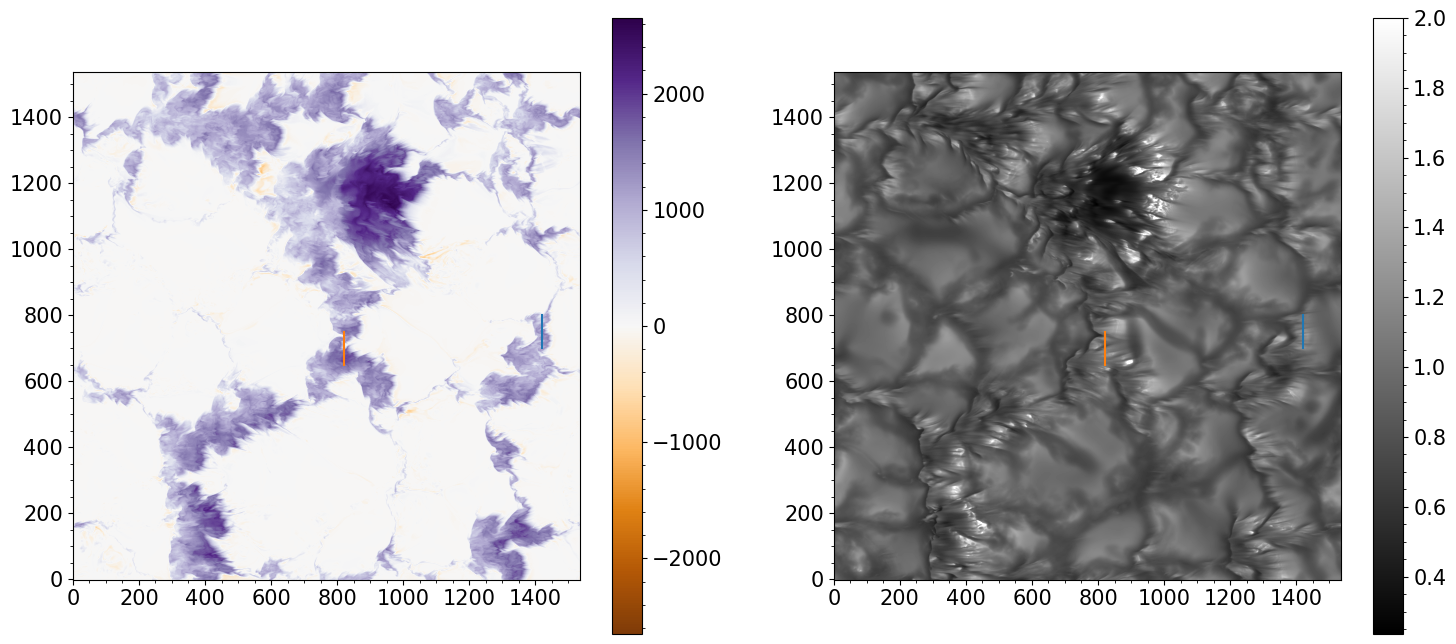

In [113]:
plt.figure(figsize=(18,8))
plt.subplot(121)
plt.imshow(Bz[:,:,20].T,origin='lower',cmap='PuOr',norm=CenteredNorm())
plt.colorbar()
plt.plot([1420,1420],[700,800])
plt.plot([x,x],[y1,y2])
plt.subplot(122)
plt.imshow(stokes.stki[100,:,:].T,origin='lower',cmap='gray',vmax=2)
plt.colorbar()
plt.plot([1420,1420],[700,800])
plt.plot([x,x],[y1,y2])

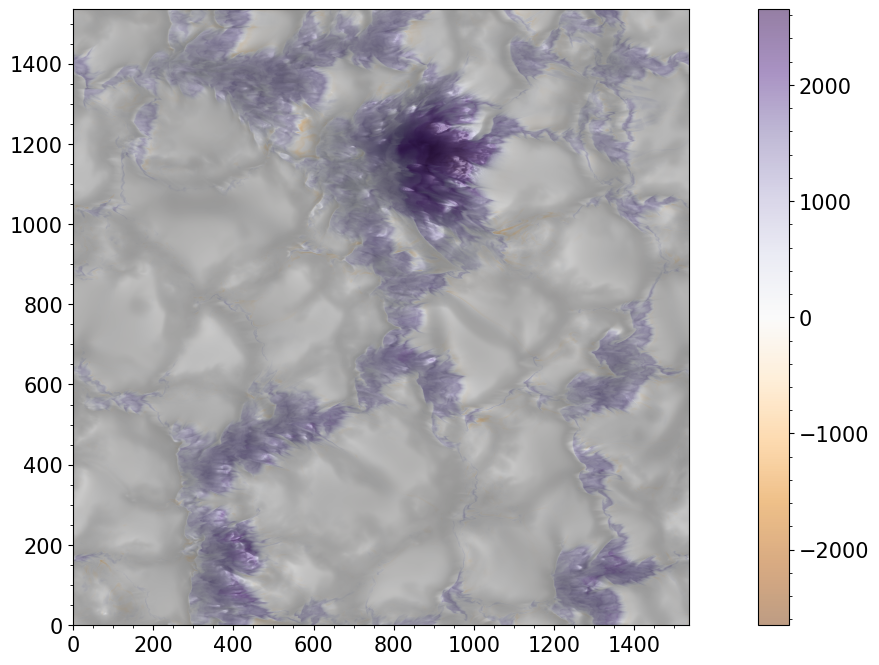

In [10]:
plt.figure(figsize=(18,8))
plt.imshow(stokes.stki[100,:,:].T,origin='lower',cmap='gray',vmax=2)
plt.imshow(Bz[:,:,20].T,origin='lower',cmap='PuOr',norm=CenteredNorm(),alpha=0.5)

plt.colorbar()

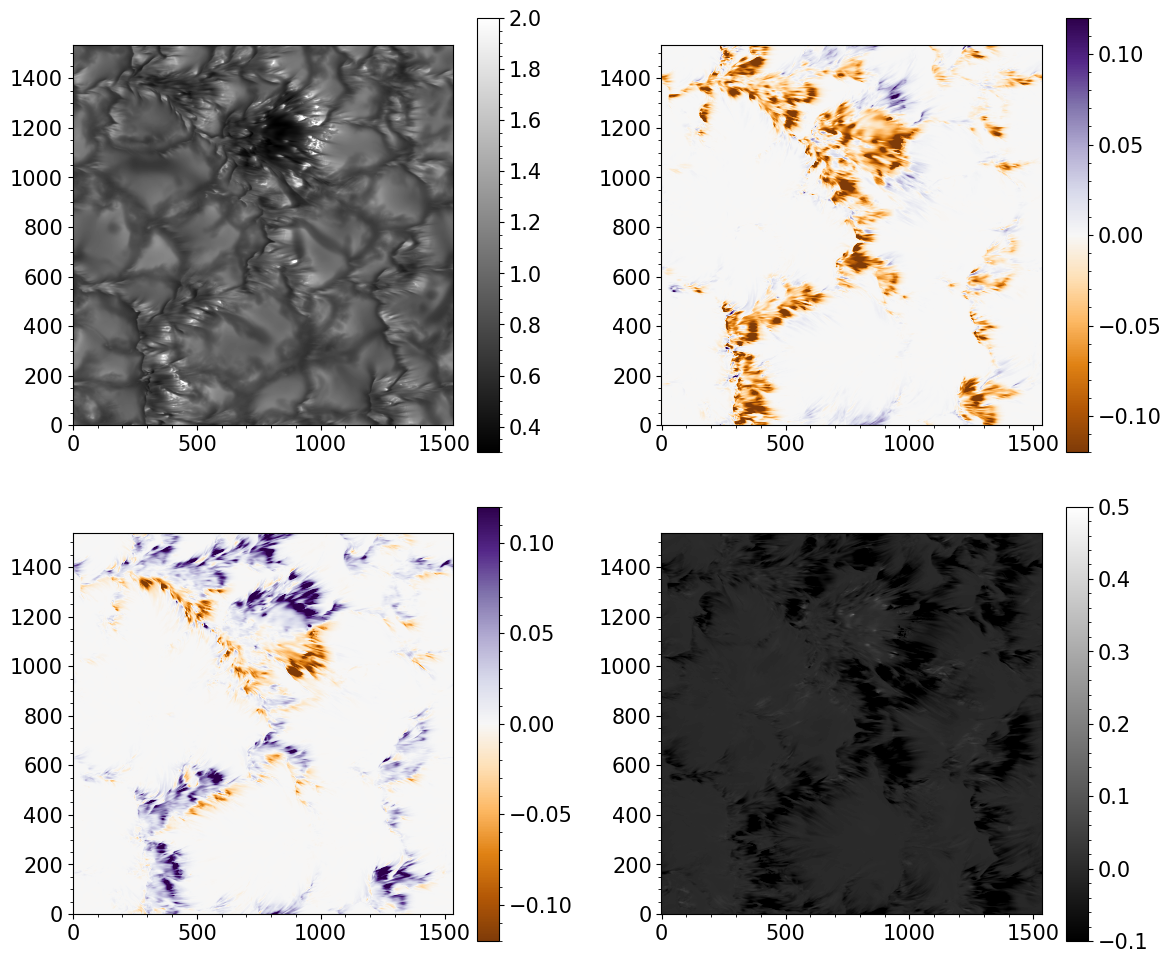

In [115]:
plt.figure(figsize=(12,10))
plt.subplot(221)
plt.imshow(stokes.stki[10,:,:].T,origin='lower',cmap='gray',vmin=0.3,vmax=2)
#plt.ylabel('y [Mm]')
#plt.title('Stokes I')
plt.colorbar()
plt.subplot(222)
plt.imshow(stokes.stkq[142,:,:].T,origin='lower',cmap='PuOr',vmin=-0.12,vmax=0.12)
#plt.title('Stokes Q')
plt.colorbar()
plt.subplot(223)
plt.imshow(stokes.stku[142,:,:].T,origin='lower',cmap='PuOr',vmin=-0.12,vmax=0.12)
#plt.title('Stokes U')
#plt.xlabel('x [Mm]')
#plt.ylabel('y [Mm]')
plt.colorbar()
plt.subplot(224)
plt.imshow(stokes.stkv[147,:,:].T,origin='lower',cmap='gray',vmin=-0.1,vmax=0.5)
#plt.title('Stokes V')
#plt.xlabel('x [Mm]')
plt.colorbar()
plt.tight_layout()
#plt.savefig('stkmap.png',bbox_inches='tight')
#plt.savefig('stkmap.eps',bbox_inches='tight')

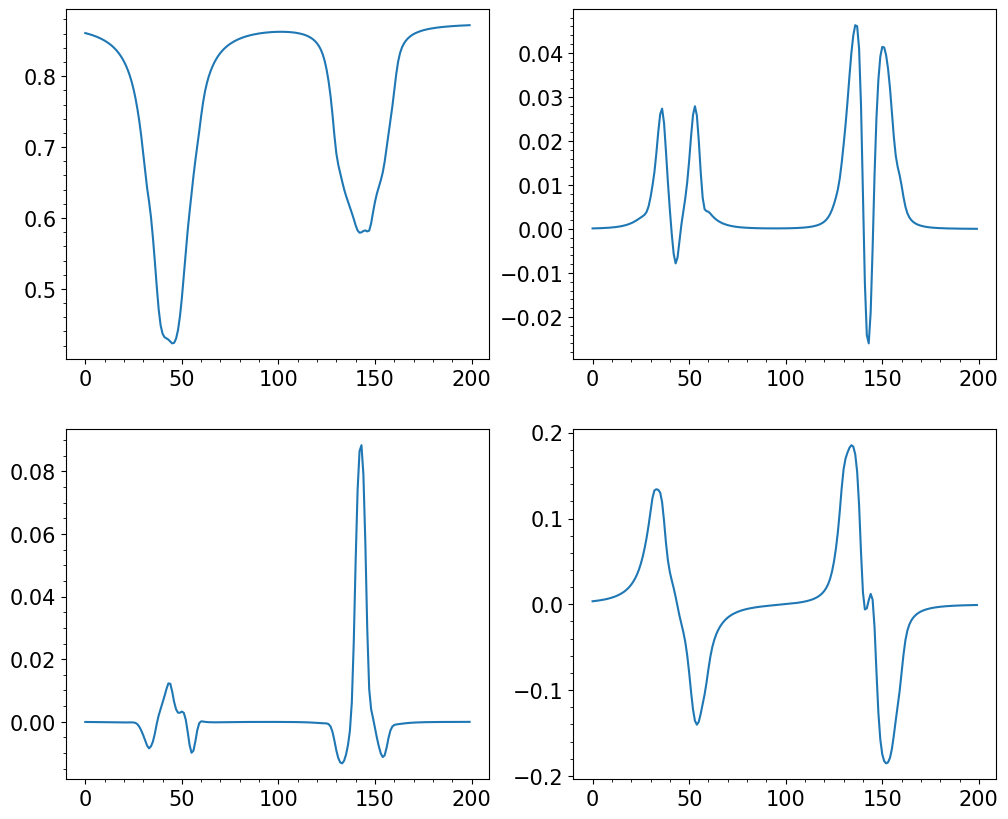

In [89]:
x = 400
y = 200
plt.figure(figsize=(12,10))
plt.subplot(221)
plt.plot(stokes.stki[:,x,y])
plt.subplot(222)
plt.plot(stokes.stkq[:,x,y])
plt.subplot(223)
plt.plot(stokes.stku[:,x,y])
plt.subplot(224)
plt.plot(stokes.stkv[:,x,y])

In [22]:
from scipy.ndimage import gaussian_filter
stokes_sigma1 = gaussian_filter(stokes.stki[100,:,:],1)
stokes_sigma3 = gaussian_filter(stokes.stki[100,:,:],3)

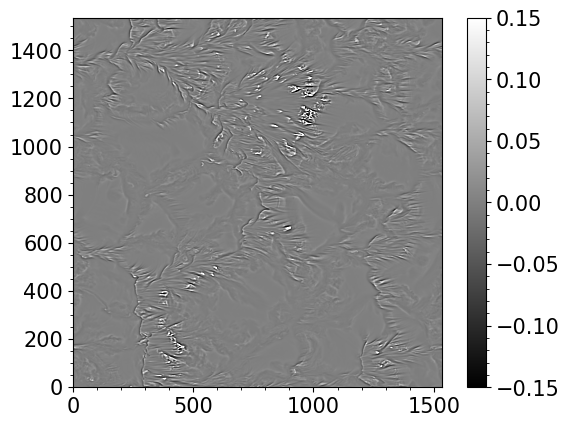

In [46]:
plt.imshow((stokes_sigma1-stokes_sigma3).T,origin='lower',cmap='gist_gray',vmax=0.15,vmin=-0.15)
plt.colorbar()

In [35]:
950/8.5

111.76470588235294

Text(0.5, 0, 'x [km]')

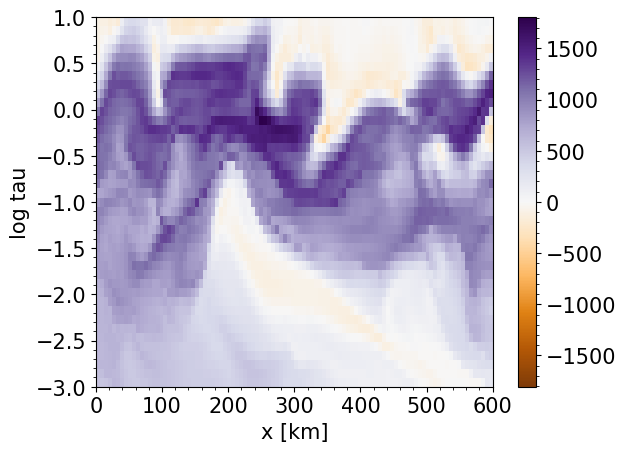

In [103]:
plt.imshow(Bz[1400,700:800,:].T,origin='lower',cmap='PuOr',norm=CenteredNorm(),extent=[0,100*6,-3,1], aspect='auto')
plt.colorbar()
plt.ylabel('log tau')
plt.xlabel('x [km]')

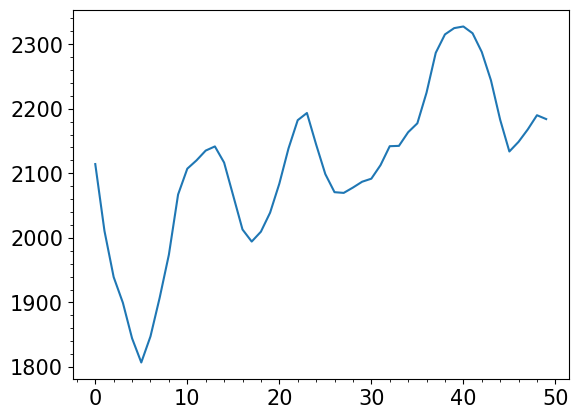

In [36]:
plt.plot(Bz[400,150:200,30])

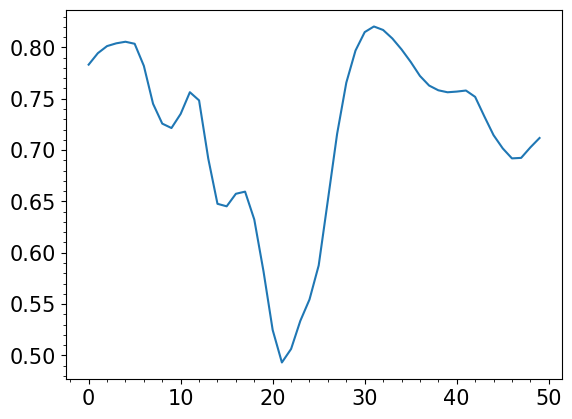

In [118]:
plt.plot(stokes.stki[100,400,150:200])

Text(0, 0.5, 'Bz')

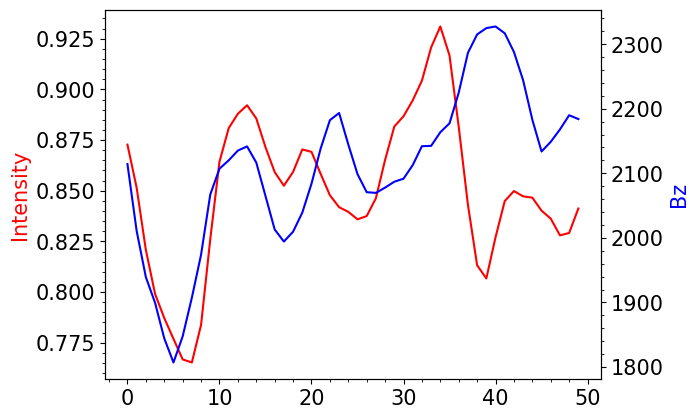

In [ ]:
fig, ax1 = plt.subplots()

ax1.plot(stokes.stki[100,400,150:200],color='red')
ax1.set_ylabel('Intensity', color='red')

ax2 = ax1.twinx()

ax2.plot(Bz[400,150:200,30],color='blue')
ax2.set_ylabel('Bz',color='blue')

#ax2.plot(atm.bz[400,150:200,112],color='orange')



Text(0, 0.5, 'V')

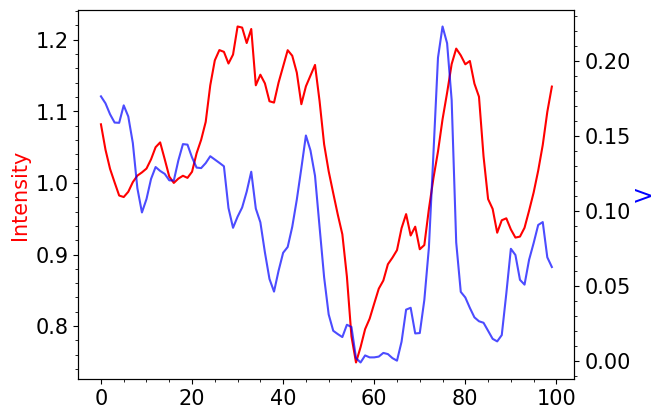

In [112]:
x = 820
y1 = 650
y2 =750
fig, ax1 = plt.subplots()

ax1.plot(stokes.stki[100,x,y1:y2],color='red')
ax1.set_ylabel('Intensity', color='red')

ax2 = ax1.twinx()

#ax2.plot(Bz[400,150:200,30],color='blue')
#ax2.set_ylabel('Bz',color='blue')

#ax2.plot(atm.bz[400,150:200,112],color='orange')

ax2.plot(stokes.stkv[130,x,y1:y2]/stokes.stki[100,x,y1:y2],color='blue',alpha=0.7)
ax2.set_ylabel('V',color='blue')



Text(0, 0.5, 'Bz')

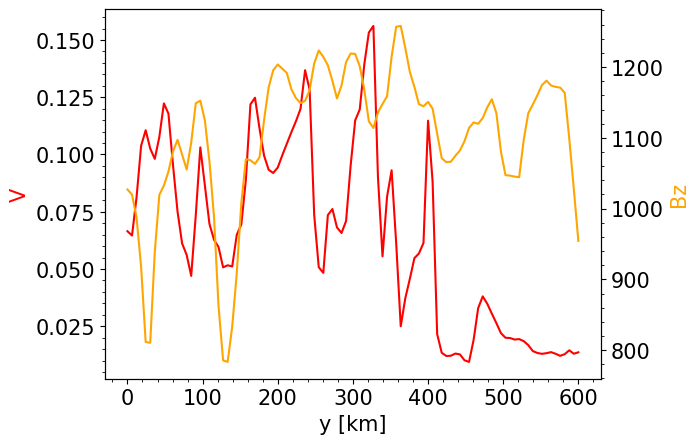

In [95]:
fig, ax1 = plt.subplots()
x = np.linspace(0,600,100)
ax1.plot(x,np.abs(stokes.stkv[130,1420,700:800]),color='red')
ax1.set_ylabel('V', color='red')
ax1.set_xlabel('y [km]')

ax2 = ax1.twinx()
#ax2.plot(x,stokes.stkv[150,1420,700:800],color='blue')
#ax2.plot(Bz[1400,700:800,30],color='blue')
#ax2.set_ylabel('Bz',color='blue')

ax2.plot(x,atm.bz[1420,700:800,112],color='orange')
ax2.set_ylabel('Bz',color='orange')


In [54]:
def gauss(x,a,x0,sigma,b):
    return a*np.exp(-(x-x0)**2/(2*sigma**2))+b

In [55]:
from scipy.optimize import curve_fit
x = np.arange(12)
y = stokes.stki[100,400,150:162]
popt, pcov = curve_fit(gauss,x,y,p0=[-1,5,2,1])

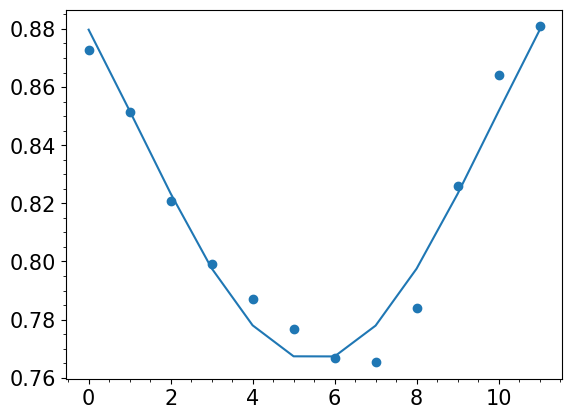

In [57]:
plt.scatter(x,y)
plt.plot(x,gauss(x,*popt))

In [58]:
2.355*popt[2]

10.145083564355712

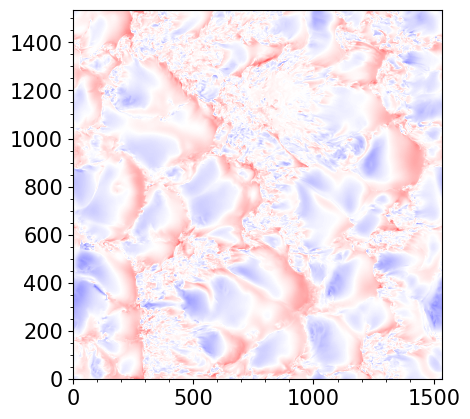

In [40]:
plt.imshow(Vz[:,:,20].T,origin='lower',cmap='bwr',norm=CenteredNorm())

In [7]:
gamma = np.arccos(atm.bz/np.sqrt(atm.bx**2+atm.by**2+atm.bz**2))*180/np.pi
gamma0 = np.arccos(atm_ori.bz/np.sqrt(atm_ori.bx**2+atm_ori.by**2+atm_ori.bz**2))*180/np.pi

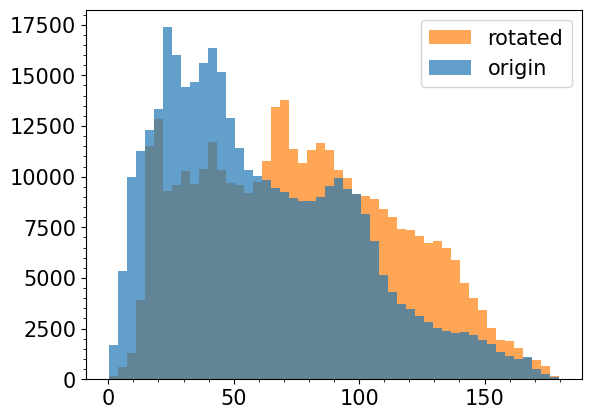

In [10]:
plt.hist([gamma0[:,756,:].flatten(),gamma[:,756,:].flatten()],bins=50,histtype='stepfilled',alpha=0.7,label=['origin','rotated'])
plt.legend()

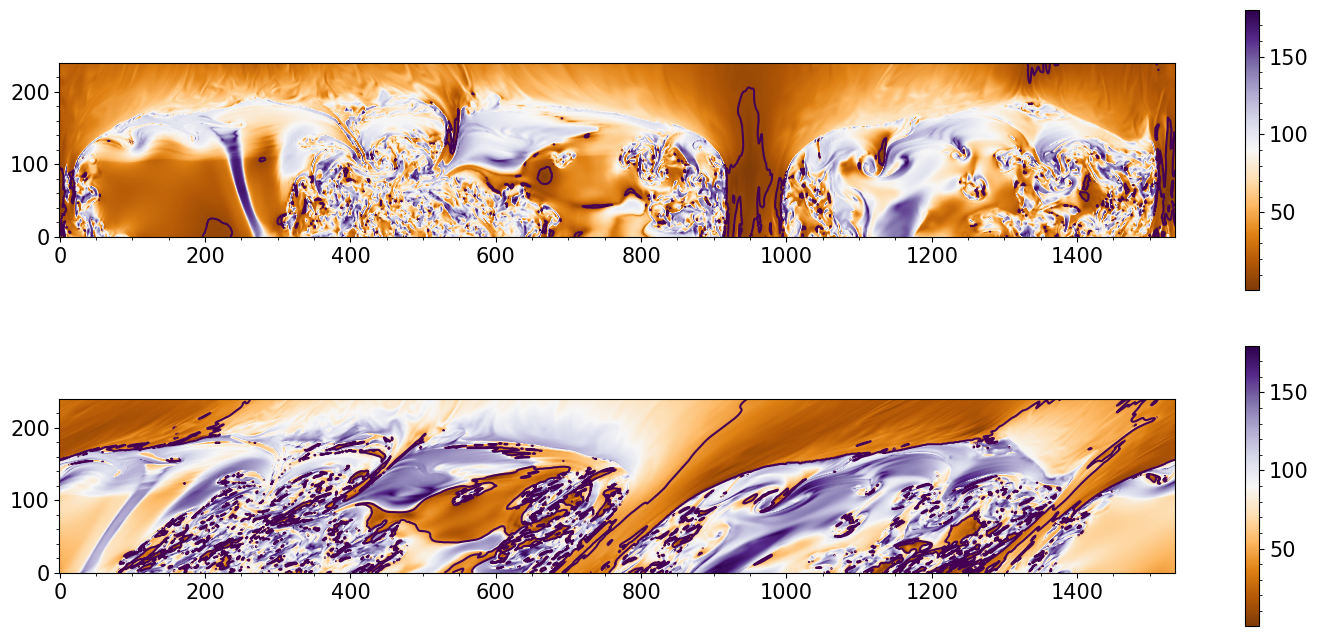

In [19]:
plt.figure(figsize=(18,8))
plt.subplot(211)
plt.imshow(gamma0[:,756,:].T,origin='lower',cmap='PuOr')
plt.colorbar()
plt.contour(gamma0[:,756,:].T,levels=[10])
plt.subplot(212)
plt.imshow(gamma[:,756,:].T,origin='lower',cmap='PuOr')
plt.colorbar()
plt.contour(gamma[:,756,:].T,levels=[45])

In [67]:
print(np.mean(z[:,:,30]))
print(np.mean(z0[:,:,30]))

855.6993816766461
587.6337985628928


Text(0.5, 1.0, '45')

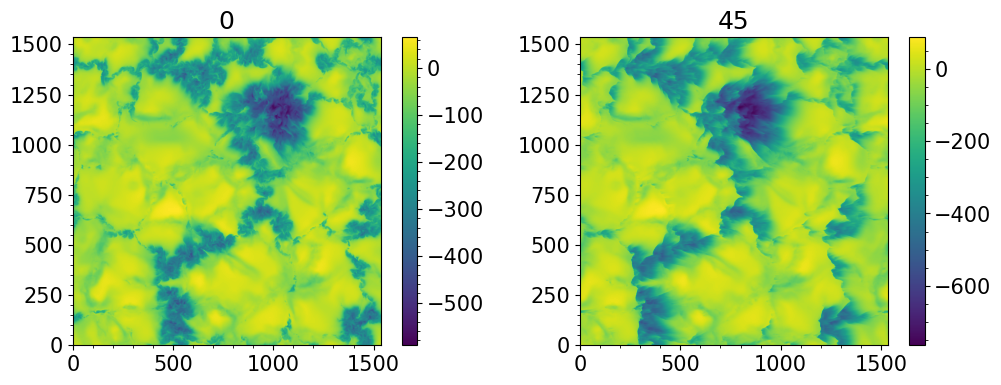

In [20]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.imshow(z0[:,:,30].T-660,origin='lower')
plt.colorbar()
plt.title('0')
plt.subplot(122)
plt.imshow(z[:,:,30].T-951,origin='lower')
plt.colorbar()
plt.title('45')

In [70]:
print(np.mean(z[200:600,600:1000,30]))
print(np.mean(z0[200:600,600:1000,30]))

951.0820798199795
660.2933428095458


In [71]:
print(np.mean(z[200:600,600:1000,30])-np.mean(z[:,:,30]))
print(np.mean(z0[200:600,600:1000,30])-np.mean(z0[:,:,30]))

95.38269814333341
72.65954424665301


## 45 degree with inverted atmos from obs

In [24]:
test = frz.read_profile('/dat/xenosh/MiHi_Fe_I_plage/TimeSeries/1/theta_test/stokes.bin')

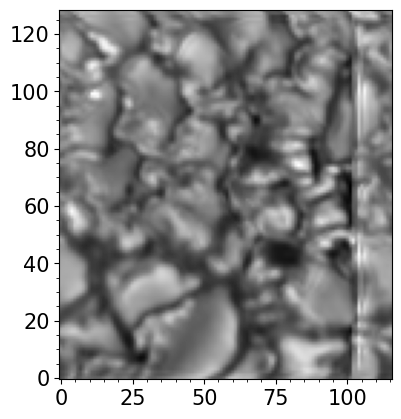

In [30]:
plt.imshow(test.stki[190,:,:].T,origin='lower',cmap='gray')


In [27]:
test_a = frz.read_model('/dat/xenosh/MiHi_Fe_I_plage/TimeSeries/1/theta_test/out_out_out_out_hsra_nx116_ny129_nz64_dz12_ME_Bh.bin')

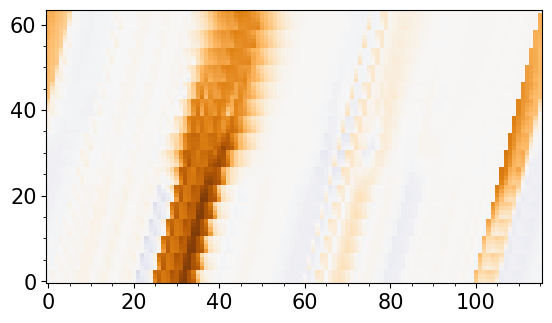

In [28]:
plt.imshow(test_a.bz[:,20,:].T,origin='lower',cmap='PuOr',norm=CenteredNorm())

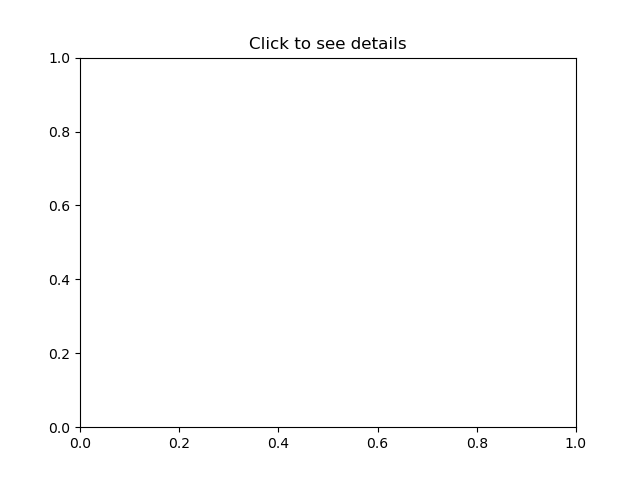

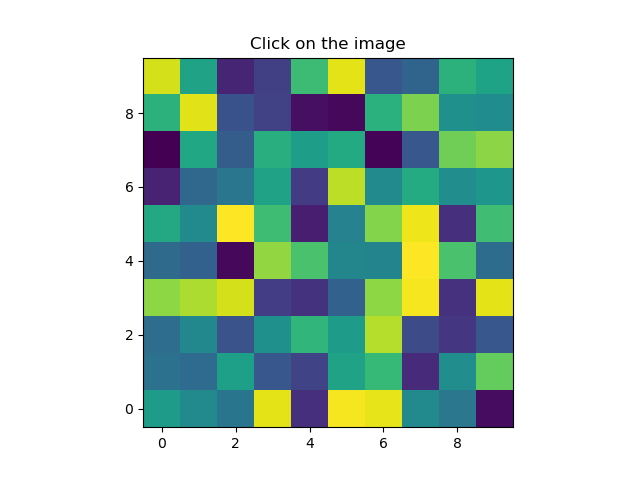

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

img = np.random.rand(10, 10)

# Create main figure
fig, ax = plt.subplots()
ax.imshow(img, cmap="viridis", origin="lower")
ax.set_title("Click on the image")

# Create a second figure for detail plot (initially empty)
fig_detail, ax_detail = plt.subplots()
ax_detail.set_title("Click to see details")

def onclick(event):
    if event.inaxes is not None:
        ix, iy = int(event.xdata), int(event.ydata)
        print(f"Clicked at x={ix}, y={iy}")

        # Clear and redraw the detail figure
        ax_detail.clear()
        ax_detail.plot(np.arange(10), img[iy, :], label=f"Row {iy}")
        ax_detail.plot(np.arange(10), img[:, ix], label=f"Col {ix}")
        ax_detail.set_title(f"Details for click at ({ix}, {iy})")
        ax_detail.legend()

        # Refresh the figure
        fig_detail.canvas.draw()

# Connect click event
cid = fig.canvas.mpl_connect("button_press_event", onclick)

plt.show()
